<a href="https://colab.research.google.com/github/PandanAdindaAfrizal/-PANDAN-ADINDA-128-ADISTI-REVI-253-_-FEATURE-ENGINEERING-/blob/main/TUGAS%20PEMROSESAN%20TEKS" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*   Pandan Adinda Afrizal (128)
*   Adisti Revi Mariska (253)



##Web Scraping with API



In [2]:
import json
import requests
import pandas as pd

url = 'https://m.21cineplex.com/api/movies?type=now-playing&city_id=72'
headers = {
    'User-Agent': (
        'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 '
        '(KHTML, like Gecko) Chrome/152.0.0.0 Safari/537.36'
    ),
    'Referer': 'https://m.21cineplex.com/id'
}

In [3]:
response = requests.get(url, headers=headers)

print('Status Code :', response.status_code)
print('Content Type:', response.headers.get('Content-Type'))

Status Code : 200
Content Type: application/json


In [4]:
try:
  data = response.json()
  with open('response.json', 'w', encoding='utf-8') as f:
    json.dump(data, f, indent=4)
except Exception:
  with open('response.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

movies = data['data']['value']['content']

print(f'Total film ditemukan: {len(movies)} film\n')
print('Contoh data film pertama (Struktur JSON):')
print(json.dumps(movies[0], indent=2))

Total film ditemukan: 27 film

Contoh data film pertama (Struktur JSON):
{
  "parent_movie_id": "16IBAT",
  "dc21_parent_movie_id": "05616bb2-25ad-48b4-a4ca-84fcfe1ea2c6",
  "dc21_parent_movie_code": "16IBAT",
  "sub_type": {
    "imax": false,
    "premiere": false,
    "xxi": true
  },
  "title": "IBU, BAGAIMANA AKU TANPAMU?",
  "duration": 111,
  "genre": "Drama, Family",
  "age_limit": 1,
  "rating": "SU",
  "movie_type": "2D",
  "distributor": "b76b1284-cd8b-4e9a-833d-c288b4bcbea2",
  "producer": "Frederica",
  "director": "Herwin Novianto",
  "writer": "Alim Sudio",
  "player": "Marsha Timothy, Fara Shakila, Praz Teguh, Ivan Gunawan, Sara Wijayanto, Kiki Narendra, Queen Lubis, Papham, Haruka Nakagawa, Kinaryosih",
  "site": "",
  "synopsis": "Setelah divonis hidupnya tak akan lama lagi, seorang ibu tunggal yang bekerja sebagai perancang gaun pengantin bertekad menghabiskan sisa waktunya untuk membahagiakan putrinya sekaligus mempersiapkannya agar mampu hidup mandiri.",
  "can_buy

In [5]:
titles = []
genres = []
durations = []
ratings = []
directors = []

print('=== DAFTAR FILM ===')
for item in movies:
  title = item.get('title', '-')
  genre = item.get('genre', '-')
  duration = item.get('duration', 0)
  rating = item.get('rating', '-')
  director = item.get('director', '-')

  titles.append(title)
  genres.append(genre)
  durations.append(duration)
  ratings.append(rating)
  directors.append(director)

  print(
      f'Judul: {title} | Genre: {genre} | Durasi: {duration} mnt | Rating:'
      f' {rating}'
  )

=== DAFTAR FILM ===
Judul: IBU, BAGAIMANA AKU TANPAMU? | Genre: Drama, Family | Durasi: 111 mnt | Rating: SU
Judul: AVENGERS ENDGAME: ENCORE | Genre: Action, Adventure, Fantasy | Durasi: 186 mnt | Rating: R13+
Judul: DANIEL AND THE FIERY FURNACE | Genre: Drama | Durasi: 108 mnt | Rating: R13+
Judul: RESIDENT EVIL | Genre: Psychological Thriller, Sci-Fi | Durasi: 94 mnt | Rating: D17+
Judul: WARGA RUSUN 609 | Genre: Comedy, Horror | Durasi: 103 mnt | Rating: R13+
Judul: AGENSI RUMAH TANGGA | Genre: Comedy, Drama | Durasi: 115 mnt | Rating: R13+
Judul: VERITY | Genre: Psychological Thriller | Durasi: 117 mnt | Rating: D17+
Judul: HASUT | Genre: Horror, Mystery | Durasi: 96 mnt | Rating: D17+
Judul: LOBANG BUAYA: 309 HARI SEBELUM TRAGEDI BERDARAH | Genre: Horror | Durasi: 99 mnt | Rating: D17+
Judul: DIGGER | Genre: Comedy, Thriller | Durasi: 129 mnt | Rating: D17+
Judul: MEMBURU PEMANGSA | Genre: Action, Crime, Horror | Durasi: 115 mnt | Rating: D17+
Judul: FORGOTTEN ISLAND | Genre: Adve

In [6]:
df = pd.DataFrame({
    'Judul Film': titles,
    'Genre': genres,
    'Durasi (Menit)': durations,
    'Rating Usia': ratings,
    'Sutradara': directors,
})

df.to_csv('hasil_scraping_mtix.csv', index=False, encoding='utf-8-sig')

df

,Judul Film,Genre,Durasi (Menit),Rating Usia,Sutradara
0,"IBU, BAGAIMANA AKU TANPAMU?","Drama, Family",111,SU,Herwin Novianto
1,AVENGERS ENDGAME: ENCORE,"Action, Adventure, Fantasy",186,R13+,"Anthony Russo, Joe Russo"
2,DANIEL AND THE FIERY FURNACE,Drama,108,R13+,"Matthew Kooman, Daniel Kooman"
3,RESIDENT EVIL,"Psychological Thriller, Sci-Fi",94,D17+,Zach Cregger
4,WARGA RUSUN 609,"Comedy, Horror",103,R13+,Herwin Novianto
5,AGENSI RUMAH TANGGA,"Comedy, Drama",115,R13+,Naya Anindita
6,VERITY,Psychological Thriller,117,D17+,Michael Showalter
7,HASUT,"Horror, Mystery",96,D17+,Ilya Sigma
8,LOBANG BUAYA: 309 HARI SEBELUM TRAGEDI BERDARAH,Horror,99,D17+,Hanung Bramantyo
9,DIGGER,"Comedy, Thriller",129,D17+,Alejandro G. Inarritu


## preprocess the text


In [7]:
!pip install git+https://github.com/ariaghora/mpstemmer.git python-Levenshtein wordcloud openpyxl


  Cloning https://github.com/ariaghora/mpstemmer.git to /tmp/pip-req-build-3c6u234j
  Running command git clone --filter=blob:none --quiet https://github.com/ariaghora/mpstemmer.git /tmp/pip-req-build-3c6u234j
  Resolved https://github.com/ariaghora/mpstemmer.git to commit 25a5fd923af163a7eac3a5ec976984156ca8fa8b
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.4/157.4 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 62.4 MB/s eta 0:00:00
  Created wheel for mpstemmer: filename=mpstemmer-0.1.0-py3-none-any.whl size=99832 sha256=8ce5f7de8b267e3b8a7ae1356be7889a6a033587d9bcfc19baf7ca99c7fae544
  Stored in directory: /tmp/pip-ephem-wheel-cache-ujyuo_pz/wheels/d0/b9/fd/dba0c7d44e5338db51da6ffcbe96db4326db3996a403f5ced1
Successfully built mpstemmer


In [8]:
import re
import string
import pandas as pd

import nltk
from nltk.corpus import stopwords
from mpstemmer import MPStemmer

import matplotlib.pyplot as plt
from wordcloud import WordCloud
from google.colab import files

# 1. dataset stopwords resmi NLTK
nltk.download('stopwords')

# 2. kamus resmi NLTK Indonesia & Inggris
sw_indo = set(stopwords.words('indonesian'))
sw_eng = set(stopwords.words('english'))

# Menggabungkan kedua kamus resmi NLTK
ALL_STOPWORDS = sw_indo.union(sw_eng)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [9]:
# 3. Fungsi Preprocessing
def remove_html(text):
    return re.sub(r'<.*?>', '', str(text))

def remove_hashtag(text):
    return re.sub(r'#\w+', '', str(text))

def remove_rls(text):
    text = re.sub(r'https?://\S+', '', str(text))
    text = re.sub(r'www\.\S+', '', str(text))
    text = re.sub(r'\S+@\S+', '', str(text))
    return text

def remove_punctuation(text):
    text = str(text).translate(str.maketrans('', '', string.punctuation))
    return ' '.join(text.split())

def remove_stopwords(text):
    return ' '.join([word for word in str(text).split() if word.lower() not in ALL_STOPWORDS])

stemmer = MPStemmer()


In [10]:
# 4. Membaca Ulang CSV
df = pd.read_csv('hasil_scraping_mtix.csv')
df['text'] = df['Judul Film']

df['rm_html'] = df['text'].apply(remove_html)
df['rm_hashtag'] = df['rm_html'].apply(remove_hashtag)
df['lower_case'] = df['rm_hashtag'].str.lower()
df['rm_url'] = df['lower_case'].apply(remove_rls)
df['rm_punc'] = df['rm_url'].apply(remove_punctuation)

# Tahap Remove Stopwords (Gunakan fungsi yang baru)
df['rm_stopwords'] = df['rm_punc'].apply(remove_stopwords)

# Tahap Stemming
df['stem'] = df['rm_stopwords'].apply(
    lambda x: stemmer.stem_kalimat(str(x)) if pd.notnull(x) else x
)

display(df[['text', 'lower_case', 'rm_punc', 'rm_stopwords', 'stem']].head(10))

,text,lower_case,rm_punc,rm_stopwords,stem
0,"IBU, BAGAIMANA AKU TANPAMU?","ibu, bagaimana aku tanpamu?",ibu bagaimana aku tanpamu,tanpamu,tanpa
1,AVENGERS ENDGAME: ENCORE,avengers endgame: encore,avengers endgame encore,avengers endgame encore,avengers endgame encore
2,DANIEL AND THE FIERY FURNACE,daniel and the fiery furnace,daniel and the fiery furnace,daniel fiery furnace,daniel fiery furnace
3,RESIDENT EVIL,resident evil,resident evil,resident evil,resident evil
4,WARGA RUSUN 609,warga rusun 609,warga rusun 609,warga rusun 609,warga rusun 609
5,AGENSI RUMAH TANGGA,agensi rumah tangga,agensi rumah tangga,agensi rumah tangga,agens rumah tangga
6,VERITY,verity,verity,verity,verity
7,HASUT,hasut,hasut,hasut,hasut
8,LOBANG BUAYA: 309 HARI SEBELUM TRAGEDI BERDARAH,lobang buaya: 309 hari sebelum tragedi berdarah,lobang buaya 309 hari sebelum tragedi berdarah,lobang buaya 309 tragedi berdarah,lobang buaya 309 tragedi darah
9,DIGGER,digger,digger,digger,digger


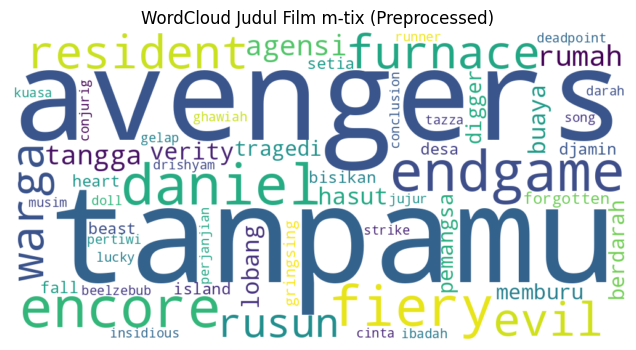

Exercise 4! File "hasil_exercise4_preprocessed.csv" telah disimpan.
 "hasil_exercise4_preprocessed.xlsx


In [11]:
# Generate WordCloud dari teks hasil preprocessing akhir
text_combined = ' '.join(df['rm_stopwords'].dropna().astype(str))
wordcloud = WordCloud(
    width=1000, height=500, background_color='white'
).generate(text_combined)

# Tampilkan Grafik WordCloud
plt.figure(figsize=(8, 4))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud Judul Film m-tix (Preprocessed)')
plt.show()

# Simpan hasil tugas Exercise 4 ke CSV dan EXCEL
df.to_csv('hasil_exercise4_preprocessed.csv', index=False, encoding='utf-8-sig')
print('Exercise 4! File "hasil_exercise4_preprocessed.csv" telah disimpan.')

df.to_excel('hasil_exercise4_preprocessed.xlsx', index=False)
print(' "hasil_exercise4_preprocessed.xlsx')

# Feature Engineering Part 1


In [17]:
import warnings

warnings.filterwarnings('ignore')

In [19]:
import pandas as pd

df = pd.read_csv('hasil_exercise4_preprocessed.csv')
df = df.dropna(subset=['rm_stopwords']).reset_index().drop(columns=['index'])

df_pre = df['rm_stopwords']
df_pre.info()

<class 'pandas.core.series.Series'>
RangeIndex: 27 entries, 0 to 26
Series name: rm_stopwords
Non-Null Count  Dtype 
--------------  ----- 
27 non-null     object
dtypes: object(1)
memory usage: 348.0+ bytes


In [20]:
# One-Hot Encoding

from sklearn.feature_extraction.text import CountVectorizer

vectorizer_ohe = CountVectorizer(binary=True)
X_ohe = vectorizer_ohe.fit_transform(df_pre)

df_ohe = pd.DataFrame(
    X_ohe.toarray(), columns=vectorizer_ohe.get_feature_names_out()
)
df_ohe.head()

,309,609,agensi,avengers,beast,beelzebub,berdarah,bisikan,buaya,cinta,...,rusun,setia,song,strike,tangga,tanpamu,tazza,tragedi,verity,warga
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,1,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1


In [21]:
#Bag of Words

vectorizer_bow = CountVectorizer()
X_bow = vectorizer_bow.fit_transform(df_pre)

df_bow = pd.DataFrame(
    X_bow.toarray(), columns=vectorizer_bow.get_feature_names_out()
)
df_bow.head()

,309,609,agensi,avengers,beast,beelzebub,berdarah,bisikan,buaya,cinta,...,rusun,setia,song,strike,tangga,tanpamu,tazza,tragedi,verity,warga
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,1,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1


In [22]:
# TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer_tfidf = TfidfVectorizer()
X_tfidf = vectorizer_tfidf.fit_transform(df_pre)

df_FE = pd.DataFrame(
    X_tfidf.toarray(), columns=vectorizer_tfidf.get_feature_names_out()
)
df_FE.head()

,309,609,agensi,avengers,beast,beelzebub,berdarah,bisikan,buaya,cinta,...,rusun,setia,song,strike,tangga,tanpamu,tazza,tragedi,verity,warga
0,0.0,0.00000,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.00000
1,0.0,0.00000,0.0,0.57735,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000
2,0.0,0.00000,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000
3,0.0,0.00000,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000
4,0.0,0.57735,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.57735,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.57735


In [26]:
df_final = pd.concat([df[['Judul Film']], df_FE], axis=1)
df_final.to_csv(
    'hasil_feature_engineering_mtix.csv', index=False, encoding='utf-8-sig'
)

with pd.ExcelWriter(
    'hasil_feature_engineering_mtix.xlsx', engine='openpyxl'
) as writer:

  pd.concat([df[['Judul Film']], df_FE], axis=1).to_excel(
      writer, sheet_name='TF-IDF', index=False
  )

  pd.concat([df[['Judul Film']], df_bow], axis=1).to_excel(
      writer, sheet_name='Bag of Words', index=False
  )

  pd.concat([df[['Judul Film']], df_ohe], axis=1).to_excel(
      writer, sheet_name='One Hot Encoding', index=False
  )

print('Data Selesai!')
print('1. File CSV   : hasil_feature_engineering_mtix.csv')
print('2. File Excel : hasil_feature_engineering_mtix.xlsx')

Data Selesai!
1. File CSV   : hasil_feature_engineering_mtix.csv
2. File Excel : hasil_feature_engineering_mtix.xlsx


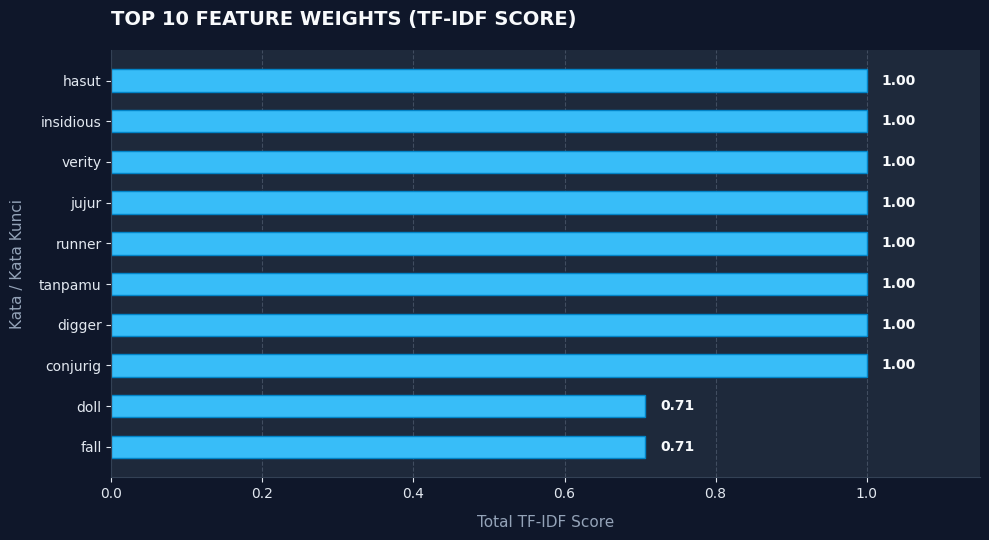

In [27]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('hasil_feature_engineering_mtix.csv')
tfidf_matrix = df.drop(columns=['Judul Film'])

top_words = tfidf_matrix.sum(axis=0).sort_values(ascending=False).head(10)
top_words_df = pd.DataFrame(
    {'Word': top_words.index, 'Score': top_words.values}
).sort_values(by='Score', ascending=True)

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 5.5), facecolor='#0f172a')
ax.set_facecolor('#1e293b')

bars = ax.barh(
    top_words_df['Word'],
    top_words_df['Score'],
    color='#38bdf8',
    height=0.55,
    edgecolor='#0284c7',
    linewidth=1,
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#334155')
ax.spines['bottom'].set_color('#334155')
ax.xaxis.grid(True, linestyle='--', alpha=0.3, color='#94a3b8')
ax.set_axisbelow(True)

for bar in bars:
  width = bar.get_width()
  ax.text(
      width + 0.02,
      bar.get_y() + bar.get_height() / 2,
      f'{width:.2f}',
      va='center',
      ha='left',
      color='#f8fafc',
      fontsize=10,
      fontweight='bold',
  )

ax.set_title(
    'TOP 10 FEATURE WEIGHTS (TF-IDF SCORE)',
    fontsize=14,
    fontweight='bold',
    color='#f8fafc',
    pad=18,
    loc='left',
)
ax.set_xlabel('Total TF-IDF Score', fontsize=11, color='#94a3b8', labelpad=10)
ax.set_ylabel('Kata / Kata Kunci', fontsize=11, color='#94a3b8', labelpad=10)
ax.tick_params(colors='#e2e8f0', labelsize=10)
ax.set_xlim(0, top_words_df['Score'].max() * 1.15)

plt.tight_layout()
plt.savefig('single_tfidf_chart.png', dpi=300, bbox_inches='tight')
plt.show()